## PHASE 5: MULTIVARIATE ANALYSIS

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(r'D:\chennai1-pg-price-predictor\Data\processed\EDA\01_eda_Phase-2_processed.csv')

## 5.1 Close the Phase 4 Loop

In [8]:
group_means = df.groupby(['locality', 'occupancy'])['rent'].mean()

def expected_rent_for_parking(parking_value):
    subset = df[df['parking'] == parking_value]
    mix = subset.groupby(['locality', 'occupancy']).size()
    mix = mix / mix.sum()
    
    total = 0
    for (loc, occ), weight in mix.items():
        if (loc, occ) in group_means.index:
            total += weight * group_means[(loc, occ)]
    return total

parking_values = df['parking'].dropna().unique()

results = []
for p in parking_values:
    expected = expected_rent_for_parking(p)
    actual = df[df['parking'] == p]['rent'].mean()
    results.append({
        'parking': p,
        'expected_locality_occupancy_adjusted': round(expected, 0),
        'actual_mean_rent': round(actual, 0),
        'residual': round(actual - expected, 0)
    })

parking_adjusted = pd.DataFrame(results).set_index('parking')
print(parking_adjusted)

              expected_locality_occupancy_adjusted  actual_mean_rent  residual
parking                                                                       
Bike                                        7652.0            7719.0      67.0
Bike and Car                                7789.0            7908.0     120.0
none                                        7454.0            6464.0    -990.0
Car                                         8536.0            9103.0     567.0


## 5.2 Multi-way Confound Checks

parking                          Bike  Bike and Car      Car    none
locality                                                            
East Coast Road-Thiruvanmiyur  8891.0        8625.0   8167.0  8800.0
Guindy                         7900.0           NaN      NaN  6600.0
New Perungalathur              6278.0        6800.0      NaN  5755.0
OMR-Karappakam                 7521.0        8767.0   7875.0  7233.0
Saidapet                       6944.0           NaN  10500.0  6650.0
Sholinganallur                 8033.0        8400.0      NaN  7667.0
Tambaram                       8277.0           NaN      NaN  4250.0
Tharamani                      7799.0        6743.0      NaN  6711.0
Vadapalani                     7629.0       10289.0      NaN  4850.0
Velachery                      7765.0        5929.0   5200.0  7818.0


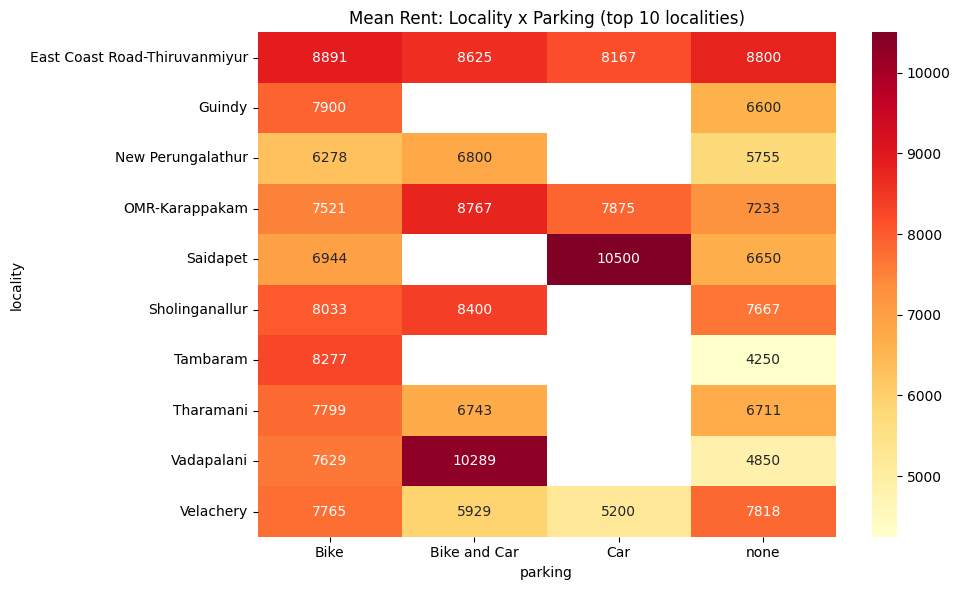

In [9]:
top_localities = df['locality'].value_counts().head(10).index
temp = df[df['locality'].isin(top_localities)]

pivot = temp.pivot_table(
    index='locality',
    columns='parking',
    values='rent',
    aggfunc='mean'
)

print(pivot.round(0))

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Mean Rent: Locality x Parking (top 10 localities)')
plt.tight_layout()
plt.show()

In [10]:
pivot2 = df.pivot_table(
    index='gender',
    columns='available_for',
    values='rent',
    aggfunc='mean'
)

print(pivot2.round(0))

# Same thing, but also splitting by occupancy to fully triangulate
pivot3 = df.pivot_table(
    index=['gender', 'available_for'],
    columns='occupancy',
    values='rent',
    aggfunc='mean'
)

print(pivot3.round(0))

available_for     Both  Student  Working Professional
gender                                               
BOTH           10100.0      NaN               19500.0
FEMALE          7730.0   6500.0                8470.0
MALE            7220.0   5643.0                9318.0
occupancy                     DOUBLE     FOUR   SINGLE    THREE
gender available_for                                           
BOTH   Both                   9667.0   7000.0  12800.0   8375.0
       Working Professional  14500.0  25000.0  22250.0  13500.0
FEMALE Both                   8269.0   6707.0  10216.0   7301.0
       Student                6500.0      NaN      NaN      NaN
       Working Professional   9265.0   6950.0  13083.0   7705.0
MALE   Both                   7551.0   6262.0   9675.0   6849.0
       Student                5750.0   7000.0   1500.0   8000.0
       Working Professional   9062.0   6875.0  14042.0   7767.0


## 5.3 Numerical Multivariate View

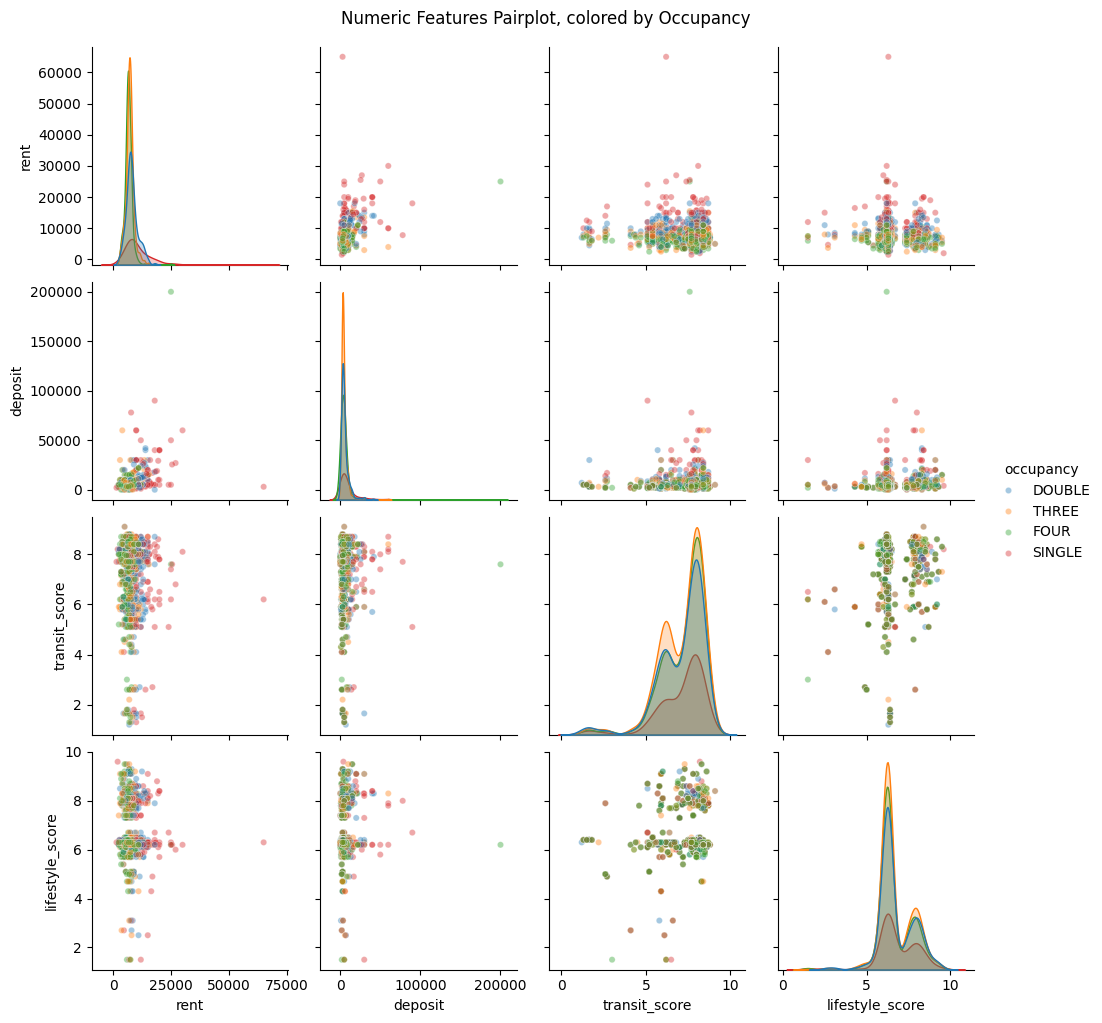

In [12]:
numeric_cols = ['rent', 'deposit', 'transit_score', 'lifestyle_score']


sns.pairplot(
    df[numeric_cols + ['occupancy']],
    hue='occupancy',
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 20}
)
plt.suptitle('Numeric Features Pairplot, colored by Occupancy', y=1.02)
plt.show()

## 5.4 Composite/Engineered Feature Candidates

occupancy                      DOUBLE    FOUR   SINGLE   THREE
locality                                                      
East Coast Road-Thiruvanmiyur  8833.0  6500.0  12636.0  7393.0
Guindy                         9182.0  6921.0   9125.0  7669.0
New Perungalathur              6644.0  5823.0   6443.0  6364.0
OMR-Karappakam                 8194.0  6438.0  11100.0  7120.0
Saidapet                       7523.0  6667.0  10250.0  6375.0
Sholinganallur                 8944.0  6774.0  10273.0  7716.0
Tambaram                       7714.0  7273.0  10078.0  7833.0
Tharamani                      8213.0  6545.0  11148.0  7390.0
Vadapalani                     7886.0  6865.0  11464.0  7095.0
Velachery                      7529.0  6492.0  10383.0  6746.0
occupancy                      single_four_gap
locality                                      
East Coast Road-Thiruvanmiyur           6136.0
OMR-Karappakam                          4662.0
Tharamani                               4603.0
Vadapalan

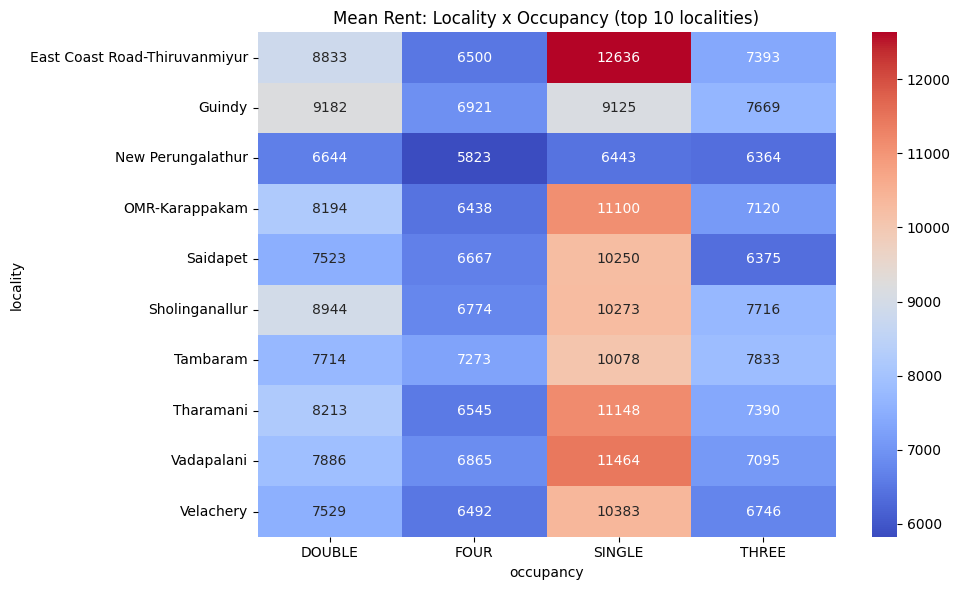

In [14]:
top10 = df['locality'].value_counts().head(10).index
temp = df[df['locality'].isin(top10)]

loc_occ_table = (
    temp.groupby(['locality', 'occupancy'])['rent']
    .mean()
    .unstack()
    .round(0)
)

print(loc_occ_table)

# Quantify the gap directly per locality
loc_occ_table['single_four_gap'] = loc_occ_table['SINGLE'] - loc_occ_table['FOUR']
print(loc_occ_table[['single_four_gap']].sort_values('single_four_gap', ascending=False))

plt.figure(figsize=(10, 6))
sns.heatmap(loc_occ_table.drop(columns='single_four_gap'), annot=True, fmt='.0f', cmap='coolwarm')
plt.title('Mean Rent: Locality x Occupancy (top 10 localities)')
plt.tight_layout()
plt.show()

In [15]:
outlier_row = df[(df['deposit'] > 100000) & (df['rent'] < 30000)]
print(outlier_row.T)  # transpose so you can read every column top to bottom

                                         1322
latitude                            13.060267
longitude                           80.211352
locality                           Vadapalani
gender                                   BOTH
available_for            Working Professional
transit_score                             7.6
lifestyle_score                           6.2
occupancy                                FOUR
rent                                  25000.0
deposit                              200000.0
attached_bathroom                        True
food_included                           False
breakfast                               False
lunch                                   False
dinner                                  False
mess                                    False
wifi                                    False
laundry                                 False
power_backup                            False
refrigerator                            False
common_tv                         

In [16]:
# Drop the row — it's inconsistent enough that "correcting" a guessed value
# would just be introducing a different unverified number

df = df[~((df['deposit'] == 200000) & (df['rent'] == 25000) & (df['locality'] == 'Vadapalani'))]

# Verify it's gone
print(df[df['deposit'] > 100000])  # should now be empty or show only genuinely plausible rows

Empty DataFrame
Columns: [latitude, longitude, locality, gender, available_for, transit_score, lifestyle_score, occupancy, rent, deposit, attached_bathroom, food_included, breakfast, lunch, dinner, mess, wifi, laundry, power_backup, refrigerator, common_tv, room_cleaning, parking, room_ac, room_cupboard, room_tv, room_geyser, room_bedding, room_attached_bath, transit_score_missing, lifestyle_score_missing]
Index: []

[0 rows x 31 columns]


In [17]:
df.groupby(['locality','parking'])['rent'].agg(['mean','count']).loc[['Saidapet','Velachery','Tambaram']]

mean  count
locality  parking                          
Saidapet  Bike           6944.444444     36
          Car           10500.000000      5
          none           6650.000000      2
Velachery Bike           7764.546512    172
          Bike and Car   5929.032258     31
          Car            5200.000000      1
          none           7818.181818     11
Tambaram  Bike           8277.272727     44
          none           4250.000000      2

In [18]:
df[(df['gender']=='BOTH') & (df['available_for']=='Working Professional')]['occupancy'].value_counts()

occupancy
SINGLE    2
DOUBLE    1
THREE     1
Name: count, dtype: int64

# PHASE 5 — Multivariate Analysis

## Summary Notebook

### Goal
Move beyond pairwise relationships and check how features behave **together**. Phase 5 also closes the open question from Phase 4: whether the parking effect remains after adjusting for locality and occupancy. fileciteturn7file0L19-L24

## 1. Close the Phase 4 Parking Question

Phase 5 calculates a locality + occupancy-adjusted expected rent for each parking category and compares it with the actual mean rent. fileciteturn7file0L58-L61

| Parking | Expected adjusted rent | Actual mean rent | Residual |
|---|---:|---:|---:|
| Car | ₹8,099 | ₹9,144 | **+₹1,045** |
| Bike | ₹7,774 | ₹7,852 | **+₹78** |
| none | ₹7,629 | ₹6,982 | **−₹647** |
| Bike and Car | ₹7,899 | ₹7,458 | **−₹442** |

### Interpretation
After controlling for **both locality and occupancy**, the Car category still has a positive residual of about ₹1,045. This means the Car premium does not disappear completely after adjustment. The Bike effect is almost neutral, while `none` and `Bike and Car` are below their adjusted expectations. fileciteturn7file0L74-L79

## 2. Multi-way Confound Check — Locality × Occupancy × Parking

Phase 5 examines parking within locality and occupancy combinations rather than relying only on overall averages. The notebook uses the top 10 localities for this comparison. fileciteturn8file0L19-L38

### Main lesson
Parking differences vary considerably by locality. Therefore, the overall parking effect should not be interpreted as a simple universal premium that is identical everywhere.

**Decision:** Keep parking as a separate feature and allow the model to learn its effect in combination with other variables.

## 3. Multi-way Confound Check — Gender × Available For × Occupancy

Phase 5 checks whether the apparent `gender = BOTH` premium still holds after considering both `available_for` and `occupancy`. fileciteturn8file0L69-L90

### Key observation
Rent differences change substantially when the analysis is split by `available_for` and occupancy. This shows that the apparent gender relationship cannot be interpreted independently of those variables.

**Decision:** Retain the relevant features and interpret the gender effect cautiously rather than treating it as a standalone causal effect.

## 4. Numeric Multivariate View

Phase 5 uses a pairplot containing:
- `rent`
- `deposit`
- `transit_score`
- `lifestyle_score`

The plots are colored by `occupancy`. The purpose is mainly to visually validate the earlier correlation analysis and look for nonlinear patterns that Pearson correlation may not capture. fileciteturn8file0L98-L102

## 5. Overall Phase 5 Lessons

### 1. Features behave differently when considered together
Pairwise relationships can be partly explained by other variables. Multivariate analysis helps separate these effects.

### 2. Parking still has an adjusted effect
After adjusting for locality and occupancy, the Car category retains a positive residual of approximately ₹1,045.

### 3. Context matters
Parking effects vary across localities, and gender-related differences vary with `available_for` and occupancy.

### 4. Visual checks complement correlation
Pairplots provide a way to identify patterns that a single Pearson correlation value may miss.

## 6. Data Quality Check

The notebook's final missing-value check shows **0 missing values across all 31 columns**. fileciteturn9file0L176-L207

Therefore, the Phase 2 cleaned dataset is ready to move into the preprocessing stage.

## 7. Final Feature / Preprocessing Plan

The Phase 5 notebook explicitly identifies the next actions: fileciteturn9file0L11-L19

| Next Step | Action |
|---|---|
| **Preprocessing** | Apply the encoding plan |
| **Skewed variables** | Apply `log1p` to `rent` and `deposit` |
| **Dataset split** | Build train, validation and test sets |
| **Feature importance** | Evaluate during baseline modeling |
| **Interaction decision** | Finalize `locality × occupancy` after baseline comparison |


## 8. Phase 5 in One Sentence

**Multivariate analysis checks whether relationships discovered in earlier phases remain when several variables are considered together, resolves confounding questions, and prepares the dataset and feature plan for preprocessing and baseline modeling.**

### Next Phase
➡️ **Preprocessing** — encoding, transformations, dataset splitting, and preparation for baseline modeling.